## Step 1: Libraries Import + Data Load

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# Load both CSV files
df1 = pd.read_csv('Unemployment in India.csv')
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

# Check the first few rows of each 
print ("Dataset 1:")
print (df1.head())

print ("\nDataset 2:")
print (df2.head())

Dataset 1:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Dataset 2:
           Region         Date  Frequency   Estimated Unem

## Step 2: Clean Column Names 

In [2]:
# Remove extra spaces from column names 
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Check column names now
print("Dataset 1 columns:", df1.columns.tolist())
print("dataset 2 columns:", df2.columns.tolist())
      

Dataset 1 columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
dataset 2 columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


## Step 3: Cleaning Missing Values and  Data Types 

In [3]:
# Check the missing values and data types of both the datasets
print("Dataset 1 Info:")
print(df1.info())

print("\nDataset 2 Info:")
print(df2.info())

Dataset 1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None

Dataset 2 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
-

## Step 4: Check Missing Values in Each Column

In [4]:
# Check how many missing values are in each column
print(df1.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


## Step 5: Remove Missing Rows

In [5]:
# Removing rows with missing valuees
df1 = df1.dropna()

# Confirm no missing values remain
print(df1.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


## Step 6: Confirm New Total Row Count

In [6]:
# Check how many rows remain after removing missing values
print("Total rows now:", df1.shape[0])

Total rows now: 740


## Step 7: Remove Extra Spaces from Date Column Values

In [7]:
# Remove leading/trailing spaces from the Date column values
df1['Date'] = df1['Date'].str.strip()

# Now convert to datetime format 
df1['Date'] = pd.to_datetime(df1['Date'], format='%d-%m-%Y')

# Confirm the data type changed
print(df1['Date'].dtype)
print(df1['Date'].head())

datetime64[ns]
0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


## Step 7: Extract Month and Year from Date

In [8]:
# Extract month and year from separate columns
df1['Month'] = df1['Date'].dt.month
df1['Year'] = df1['Date'].dt.year

# Check the new columns
print(df1[['Date' , 'Month' , 'Year']].head())

        Date  Month  Year
0 2019-05-31      5  2019
1 2019-06-30      6  2019
2 2019-07-31      7  2019
3 2019-08-31      8  2019
4 2019-09-30      9  2019


## Step 8: Visualize Overall Unemployment Trend Over Time

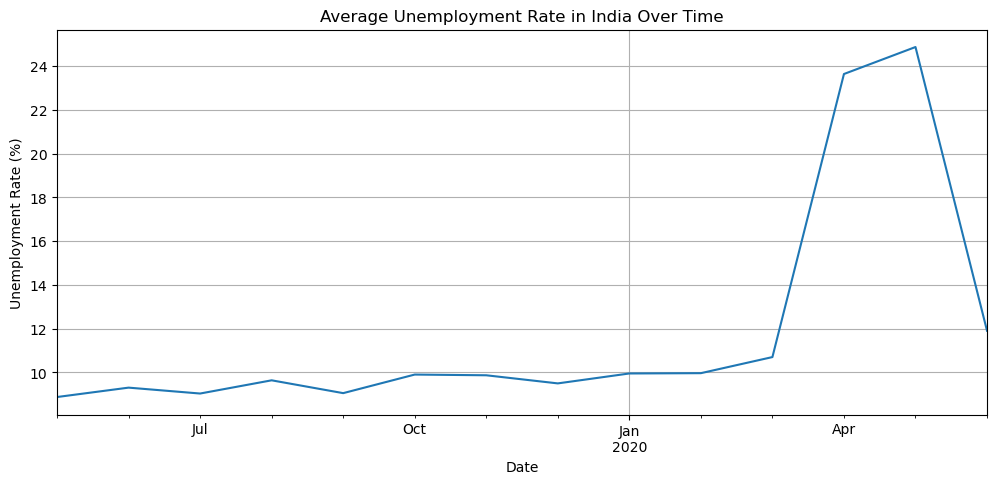

In [9]:
# Group by date to get average unemployment rate across all regions
trend = df1.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

# Plot the trend over time
plt.figure(figsize=(12,5))
trend.plot()
plt.title('Average Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()

## Step 9: Compare Unemployment by Area (Rural vs Urban)

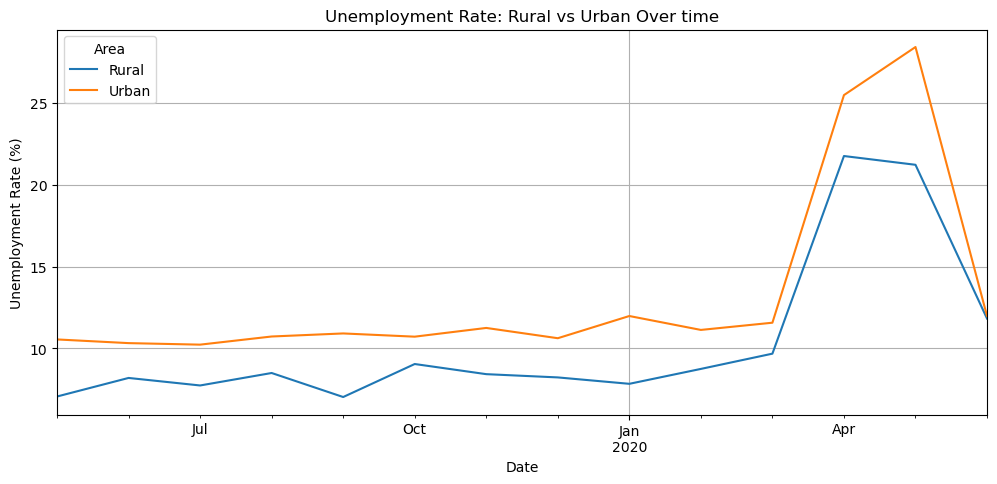

In [10]:
# Compare unemployment rate trends between Rural & Urban areas
area_trend = df1.groupby(['Date', 'Area']) ['Estimated Unemployment Rate (%)'].mean().unstack()

# Plot both trends together
plt.figure(figsize=(12, 5))
area_trend.plot(ax=plt.gca())
plt.title("Unemployment Rate: Rural vs Urban Over time")
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show;

## Step 10: State-wise Average Unemployment Rate Comparison

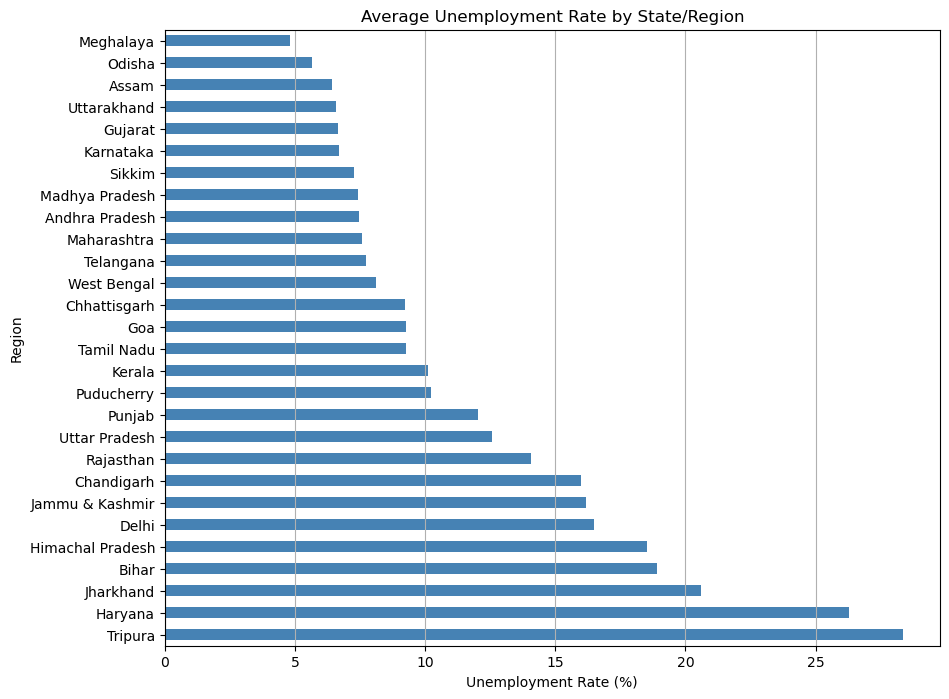

In [11]:
# Calculate average unemployment rate for each state/region
state_avg = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

# Plot as a bar chart
plt.figure(figsize=(10,8))
state_avg.plot(kind='barh', color='steelblue')
plt.title('Average Unemployment Rate by State/Region')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Region')
plt.grid(True, axis='x')
plt.show()

## Step 11: Conclusion

#### This project analyzed unemployment rate data across Indian states from mid-2019 to mid-2020, using two datasets covering both the pre-Covid period and the Covid-affected months.

### **Key Findings:**

#### 1. **Covid-19 Impact:** The average unemployment rate remained stable around 
####   8-10% before the pandemic. Following the nationwide lockdown in March 2020, 
####  unemployment spiked dramatically, peaking at nearly 25% in April-May 2020.

#### 2. **Rural vs Urban:** Urban areas were more severely affected by the lockdown than rural areas, with urban unemployment reaching close to 28% compared to  around 22% in rural areas — likely due to higher dependency on offices, factories, and daily-wage urban jobs that were shut down during the lockdown.

#### 3. **Regional Patterns:** Unemployment rates varied significantly by state even outside the Covid period. States like Tripura, Haryana, and Jharkhand  consistently showed higher average unemployment rates, while states like Meghalaya, Odisha, and Gujarat maintained comparatively lower rates,  suggesting structural/regional economic factors beyond just the pandemic.

#### **Policy Implication:** These insights suggest that pandemic-response policies should account for both the temporary shock (Covid lockdown) and pre-existing regional disparities, with targeted support for consistently high-unemployment states and urban job sectors most affected by lockdowns.

#### This project demonstrated a complete data analysis workflow: data cleaning (handling missing values, fixing column names, converting date formats), exploratory analysis, and visualization using line charts and bar charts to extract time-based and regional insights.